Import Bibliotek

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.filters import frangi

Załadowanie obrazów

In [2]:
dnoOka = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/images/0{i}_dr.jpg"
        filename2 = f"all/images/0{i}_g.jpg"
        filename3 = f"all/images/0{i}_h.jpg"
    else:
        filename1 = f"all/images/{i}_dr.jpg"
        filename2 = f"all/images/{i}_g.jpg"
        filename3 = f"all/images/{i}_h.jpg"
    # Wczytaj obrazy i konwertuj z BGR do RGB
    img1 = cv2.imread(filename1)
    img2 = cv2.imread(filename2)
    img3 = cv2.imread(filename3)
    dnoOka.append(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    dnoOka.append(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    dnoOka.append(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))

naczynia = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/manual1/0{i}_dr.tif"
        filename2 = f"all/manual1/0{i}_g.tif"
        filename3 = f"all/manual1/0{i}_h.tif"
    else:
        filename1 = f"all/manual1/{i}_dr.tif"
        filename2 = f"all/manual1/{i}_g.tif"
        filename3 = f"all/manual1/{i}_h.tif"
    naczynia.append(cv2.imread(filename1))
    naczynia.append(cv2.imread(filename2))
    naczynia.append(cv2.imread(filename3))

Funkcja do wyświetlania obrazów

In [3]:
def showImages(images):
    plt.figure(figsize=(5, 9))
    plt.imshow(images[0])

    plt.tight_layout()
    plt.show()

Obraz przed przetworzeniem

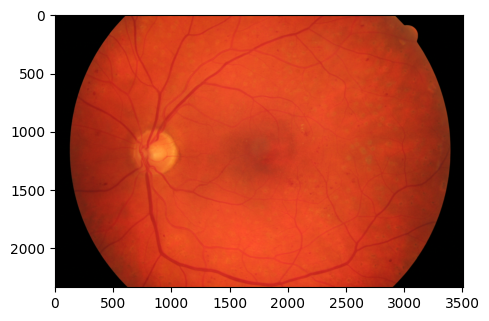

In [4]:
showImages(dnoOka)

Zmiana na czarno bialy

In [5]:
for idx in range(len(dnoOka)):
    dnoOka[idx] = cv2.cvtColor(dnoOka[idx], cv2.COLOR_BGR2GRAY)

Normalizacja Histogramu

In [6]:
from skimage import exposure
for idx in range(len(dnoOka)):
    dnoOka[idx] = exposure.equalize_adapthist(dnoOka[idx], clip_limit=0.03)

Wyostrzenie

In [7]:
from skimage.filters import unsharp_mask
for idx in range(len(dnoOka)):
    dnoOka[idx] = unsharp_mask(dnoOka[idx], radius=1, amount=1)


Rozmycie, żeby usunąć szum

In [8]:
from scipy.ndimage import gaussian_filter
for idx in range(len(dnoOka)):
    dnoOka[idx] = gaussian_filter(dnoOka[idx], sigma=1)


Obraz po podstawowej obróbce

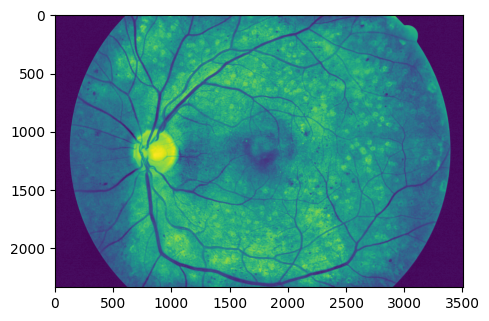

In [9]:
showImages(dnoOka)

Filtr Frangiego

In [ ]:
from skimage.filters import frangi
from skimage import img_as_float

vessels = []
for idx in range(len(dnoOka)):
    print(f"Processing image {idx + 1}/{len(dnoOka)}")
    dnoOka[idx] = img_as_float(dnoOka[idx])
    vessels.append(frangi(dnoOka[idx]))

Processing image 1/45
Processing image 2/45
Processing image 3/45
Processing image 4/45
Processing image 5/45
Processing image 6/45
Processing image 7/45
Processing image 8/45
Processing image 9/45
Processing image 10/45
Processing image 11/45
Processing image 12/45
Processing image 13/45
Processing image 14/45
Processing image 15/45
Processing image 16/45
Processing image 17/45
Processing image 18/45
Processing image 19/45
Processing image 20/45
Processing image 21/45
Processing image 22/45
Processing image 23/45
Processing image 24/45
Processing image 25/45
Processing image 26/45
Processing image 27/45
Processing image 28/45
Processing image 29/45
Processing image 30/45
Processing image 31/45
Processing image 32/45
Processing image 33/45
Processing image 34/45
Processing image 35/45
Processing image 36/45
Processing image 37/45
Processing image 38/45
Processing image 39/45
Processing image 40/45
Processing image 41/45
Processing image 42/45
Processing image 43/45
Processing image 44/

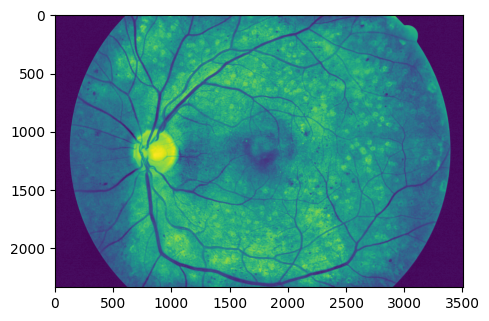

In [11]:
showImages(dnoOka)